In [7]:
import xarray as xr
import regionmask
import numpy as np

In [8]:
# === Processing functions ===
def adjust_longitude(dataset: xr.Dataset) -> xr.Dataset:
        """Swaps longitude coordinates from range (0, 360) to (-180, 180)
        Args:
            dataset (xr.Dataset): xarray Dataset
        Returns:
            xr.Dataset: xarray Dataset with swapped longitude dimensions
        """
        lon_name = "lon"  # whatever name is in the data

        # Adjust lon values to make sure they are within (-180, 180)
        dataset["_longitude_adjusted"] = xr.where(
            dataset[lon_name] > 180, dataset[lon_name] - 360, dataset[lon_name])
        dataset = (
            dataset.swap_dims({lon_name: "_longitude_adjusted"})
            .sel(**{"_longitude_adjusted": sorted(dataset._longitude_adjusted)})
            .drop_vars(lon_name)
        )

        dataset = dataset.rename({"_longitude_adjusted": lon_name})
        return dataset


# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)


# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da

In [34]:
# === Concatenate ensemble members ===
def merge_ensembles(VAR_DIR, VAR, land_mask=False):
    """ land_filter=True allows for the land filter function to remove the ocean """
    ARISE_ens = []
    SSP245_ens = []

    for ens_num in range(1, 11):
        ARISE_ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_ARISE_{ens_num:02d}_20350101-20691231.nc"))
        SSP245_ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_SSP245_{ens_num:02d}_20200101-20691231.nc"))

    arise_da = xr.concat(ARISE_ens, dim=xr.DataArray(np.arange(1, len(ARISE_ens)+1), dims="ensemble", name="ensemble"))
    ssp245_da = xr.concat(SSP245_ens, dim=xr.DataArray(np.arange(1, len(SSP245_ens)+1), dims="ensemble", name="ensemble"))

    if land_mask is True:
        print("Filtering ocean")
        arise_da = land_filter(arise_da)
        ssp245_da = land_filter(ssp245_da)

    return arise_da, ssp245_da

In [10]:
# === Path config ===
OSDMA8_DIR = "/glade/work/awells/air_quality/CESM/OSDMA8_March/"

# === Main loop ===
arise_new_t6m, ssp245_new_t6m = merge_ensembles(OSDMA8_DIR, "T6M", land_mask=True)

Filtering ocean


In [26]:
# === Path config ===
T6M_DIR = "/glade/work/awells/air_quality/CESM/T6M/"

# === Main loop ===
arise_t6m, ssp245_t6m = merge_ensembles(T6M_DIR, "T6M", land_mask=True)

Filtering ocean


In [35]:
# === Path config ===
OSDMA8_DIR = "/glade/work/awells/air_quality/CESM/OSDMA8_March/"

# === Main loop ===
arise_o3, ssp245_o3 = merge_ensembles(OSDMA8_DIR, "OSDMA8", land_mask=True)

Filtering ocean
Filtering ocean


In [86]:
# === Path config ===
OSDMA8_DIR = "/glade/work/awells/air_quality/CESM/OSDMA8_March/"

# === Main loop ===
arise_o3_m, ssp245_o3_m = merge_ensembles(OSDMA8_DIR, "OSDMA8_startmonth", land_mask=True)

Filtering ocean


In [83]:
arise = arise_t6m.sel(year=slice("2050", "2069")).mean(dim=("ensemble", "year"))
ssp245_early = ssp245_t6m.sel(year=slice("2020", "2039")).mean(dim=("ensemble", "year"))
ssp245_late = ssp245_t6m.sel(year=slice("2050", "2069")).mean(dim=("ensemble", "year"))

In [87]:
ssp245_early_m = ssp245_o3_m.sel(year=slice("2020", "2039")).mean(dim=("ensemble", "year"))
ssp245_late_m = ssp245_o3_m.sel(year=slice("2050", "2069")).mean(dim=("ensemble", "year"))

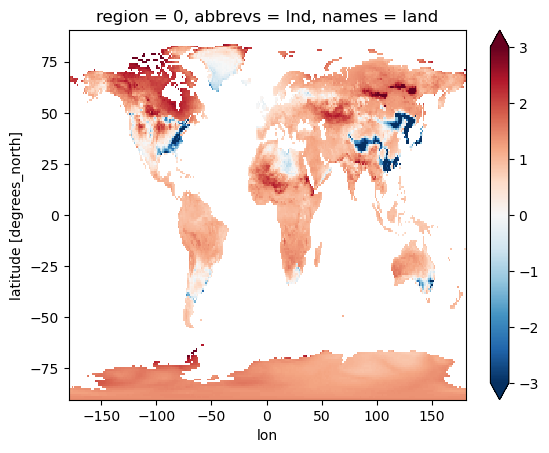

In [85]:
adjust_longitude(ssp245_late-ssp245_early).plot(vmax=3)

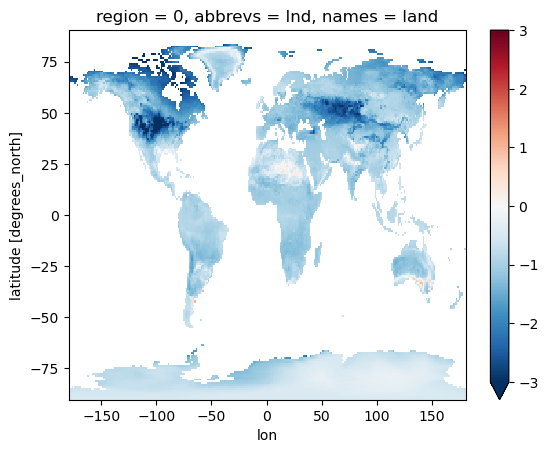

In [100]:
adjust_longitude(arise-ssp245_late).plot(vmax=3)

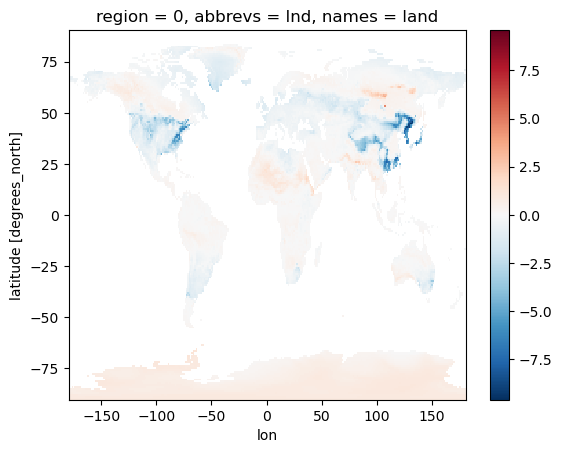

In [110]:
adjust_longitude(arise-ssp245_early).plot()

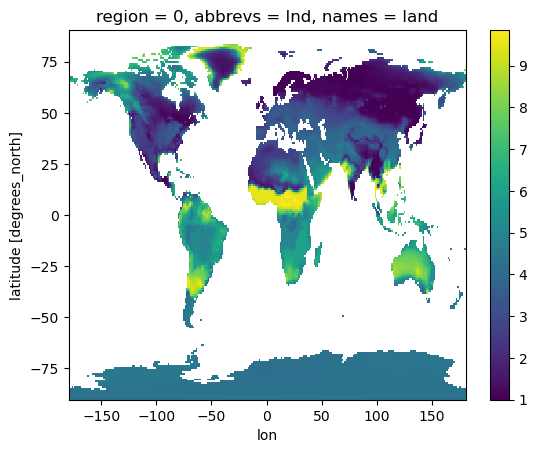

In [91]:
adjust_longitude(ssp245_late_m).plot()

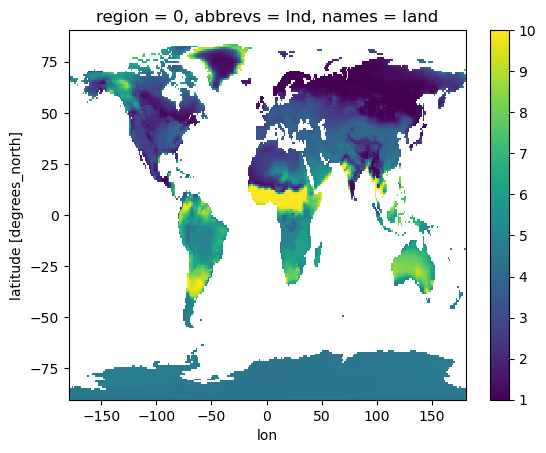

In [92]:
adjust_longitude(ssp245_early_m).plot()

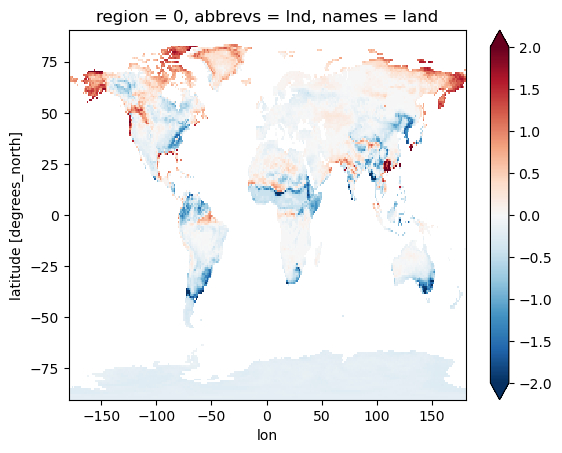

In [94]:
adjust_longitude(ssp245_late_m-ssp245_early_m).plot(vmax=2)

In [56]:
weights = np.cos(np.deg2rad(arise_t6m.lat))
arise_new_t6m_reg = arise_new_t6m.weighted(mask_3D * weights).mean(dim=("lat", "lon"))
ssp245_new_t6m_reg = ssp245_new_t6m.weighted(mask_3D * weights).mean(dim=("lat", "lon"))

arise_t6m_reg = arise_t6m.weighted(mask_3D * weights).mean(dim=("lat", "lon"))
ssp245_t6m_reg = ssp245_t6m.weighted(mask_3D * weights).mean(dim=("lat", "lon"))

arise_o3_reg = arise_o3.weighted(mask_3D * weights).mean(dim=("lat", "lon"))
ssp245_o3_reg = ssp245_o3.weighted(mask_3D * weights).mean(dim=("lat", "lon"))

In [101]:
arise_o3_points = arise_o3_reg.sel(year=slice("2050", "2069")).mean(dim=("ensemble","year"))
arise_new_t6m_points = arise_new_t6m_reg.sel(year=slice("2050", "2069")).mean(dim=("ensemble","year"))
arise_t6m_points = arise_t6m_reg.sel(year=slice("2050", "2069")).mean(dim=("ensemble","year"))

In [102]:
ssp245_o3_points = ssp245_o3_reg.sel(year=slice("2050", "2069")).mean(dim=("ensemble","year"))
ssp245_new_t6m_points = ssp245_new_t6m_reg.sel(year=slice("2050", "2069")).mean(dim=("ensemble","year"))
ssp245_t6m_points = ssp245_t6m_reg.sel(year=slice("2050", "2069")).mean(dim=("ensemble","year"))

ssp245_o3_points_e = ssp245_o3_reg.sel(year=slice("2020", "2039")).mean(dim=("ensemble","year"))
ssp245_new_t6m_points_e = ssp245_new_t6m_reg.sel(year=slice("2020", "2039")).mean(dim=("ensemble","year"))
ssp245_t6m_points_e = ssp245_t6m_reg.sel(year=slice("2020", "2039")).mean(dim=("ensemble","year"))

In [62]:
import matplotlib.pyplot as plt

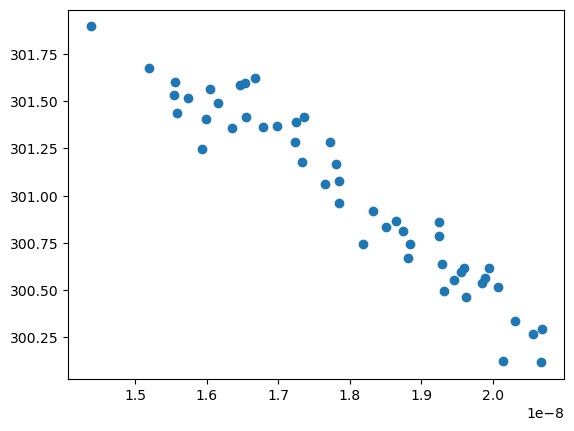

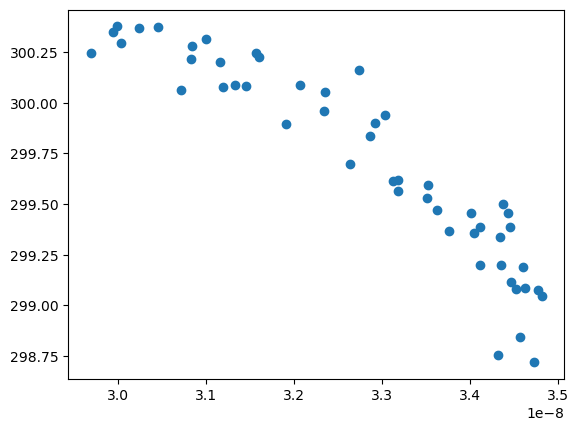

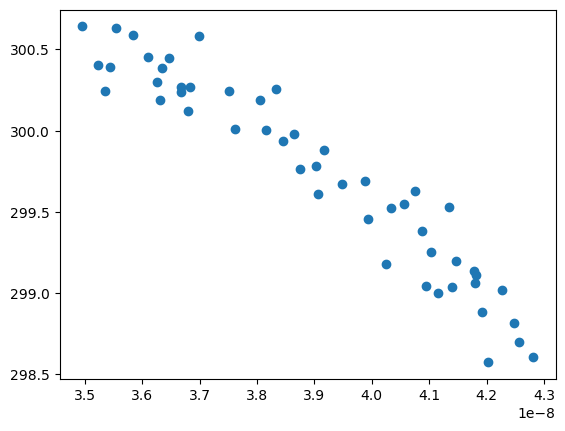

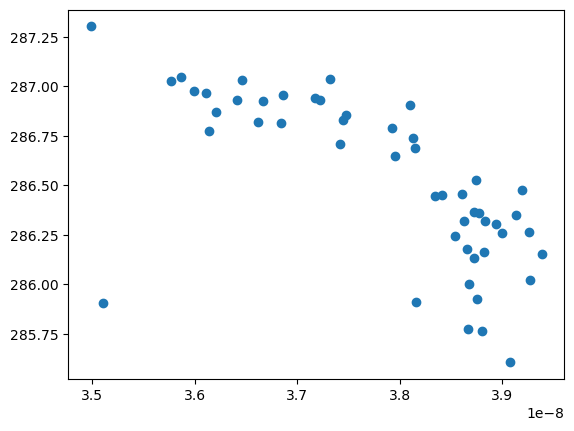

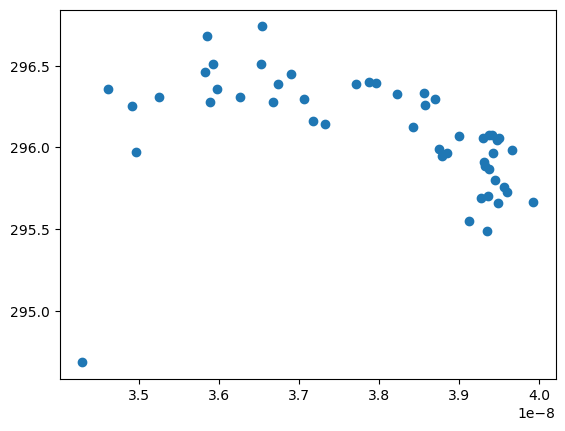

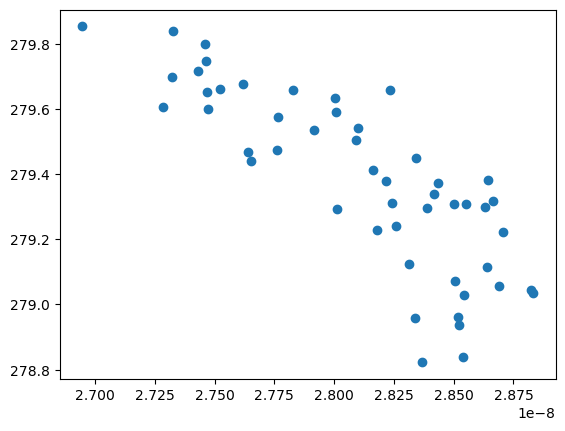

In [78]:
for i in range(10, 16):
    o3 = ssp245_o3_reg.sel(region=i).mean("ensemble")
    t6m = ssp245_t6m_reg.sel(region=i).mean("ensemble")
    plt.figure()
    plt.scatter(o3, t6m)

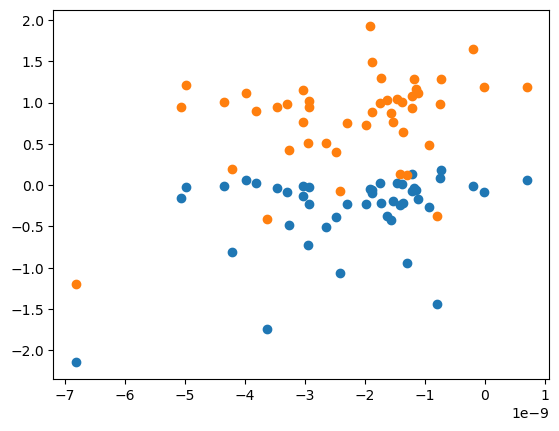

In [104]:
plt.scatter(ssp245_o3_points - ssp245_o3_points_e, ssp245_new_t6m_points - ssp245_new_t6m_points_e)
plt.scatter(ssp245_o3_points - ssp245_o3_points_e, ssp245_t6m_points - ssp245_t6m_points_e)

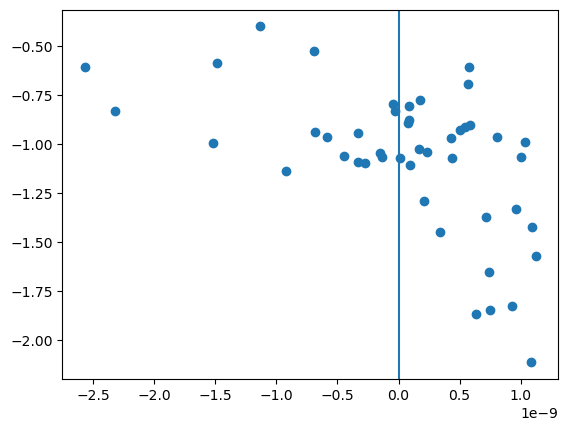

In [108]:
plt.scatter(arise_o3_points - ssp245_o3_points, arise_t6m_points - ssp245_t6m_points)
plt.axvline(0)